In [1]:
!git clone https://github.com/RudraKsh0091/AI-Image-Impainting.git
%cd AI-Image-Impainting
!pip install -r requirements.txt

Cloning into 'AI-Image-Impainting'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 124 (delta 63), reused 73 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 1.11 MiB | 6.16 MiB/s, done.
Resolving deltas: 100% (63/63), done.
Filtering content: 100% (2/2), 669.81 MiB | 5.24 MiB/s, done.
/kaggle/working/AI-Image-Impainting


In [2]:
from src.model import build_unet
from src.data import get_train_val_split, load_dataset
from src import config
import numpy as np

model = build_unet(img_size=config.IMG_SIZE)
model.load_weights("/kaggle/working/AI-Image-Impainting/models/best_model_weighted.weights.h5")
model.compile(optimizer="adam")

2026-06-21 08:02:23.498718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782028943.712678      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782028943.768883      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782028944.261086      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782028944.261131      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782028944.261133      58 computation_placer.cc:177] computation placer alr

In [3]:
model.summary()

Model: "inpainting_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 4)                │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      4,160 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    524,544 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │  2,097,664 │ leaky_re_lu_2[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  4,194,816 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                 

 Total params: 29,256,323 (111.60 MB)

 Trainable params: 29,249,539 (111.58 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [4]:
_, val_paths = get_train_val_split(config.IMAGE_DIR, num_train=config.NUM_TRAIN, num_val=config.NUM_VAL)
val_ds = load_dataset(val_paths[:8], img_size=config.IMG_SIZE, batch_size=8, mask_type='combined', fixed_seed=123)

for (masked_images, masks), originals in val_ds.take(1):
    predictions = model.predict([masked_images, masks])
    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [5]:
predictions.shape

(8, 256, 256, 3)

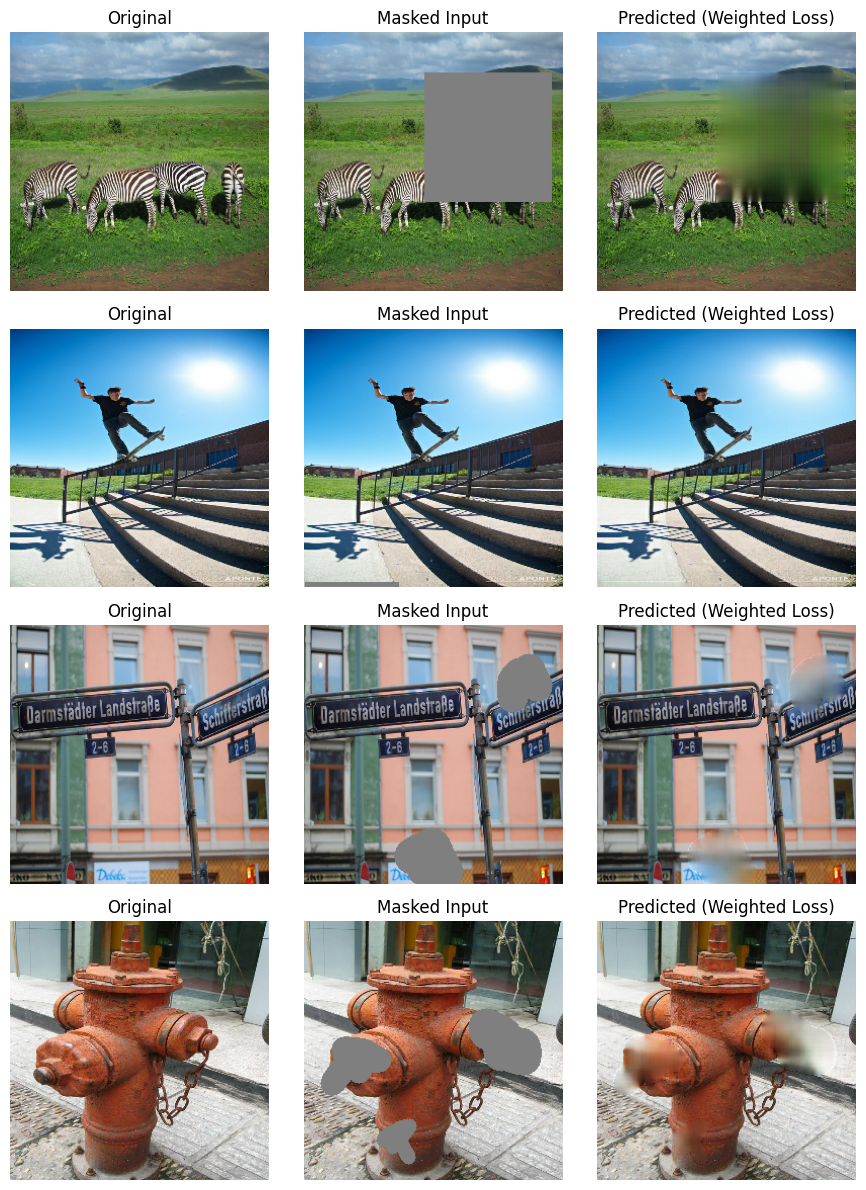

In [6]:
import matplotlib.pyplot as plt

def denormalize_image(img):
    img = (img + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(9, num_samples * 3))

for i in range(num_samples):
    original = denormalize_image(originals[i].numpy())
    masked = denormalize_image(masked_images[i].numpy())
    predicted = denormalize_image(predictions[i])

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masked)
    axes[i, 1].set_title("Masked Input")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(predicted)
    axes[i, 2].set_title("Predicted (Weighted Loss)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("evaluation_grid_weighted.png", dpi=150)
plt.show()